In [150]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

matplotlib.use("Agg")  # required to save plots to file
%matplotlib inline

# Uncomment to install UC Berkeley DataScience Library
#!pip install datascience
import datascience
from datascience import *  # https://github.com/data-8/datascience

import warnings, os, sys

warnings.filterwarnings("ignore")

print(sys.version)
print(np.__version__)
print(pd.__version__)
print(datascience.__version__)

3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 10:07:17) [Clang 14.0.6 ]
1.26.4
2.2.2
0.17.6


In [152]:
# == Configuration ==========================================================
DATA_PATH = "battery_failure_surfaces.csv"
OUTPUT_DIR = "."
CHEM_COLORS = {
    "Li-ion NMC": "#e74c3c",
    "LFP": "#27ae60",
    "Solid-State": "#2980b9",
}
PLOT_DPI = 150
EOL = 80.0  # industry-standard End-of-Life threshold (%)
sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "figure.titlesize": 14,
    }
)
plt.style.use("fivethirtyeight")

In [154]:
# == Helper =================================================================
cleaning_log = []


def log(msg):
    cleaning_log.append(msg)
    print(f"  -> {msg}")


def chem_color(c):
    return CHEM_COLORS.get(c, "#7f8c8d")


def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> Saved {path}")


def minmax(s):
    """Min-max normalise a pandas Series to [0, 1]."""
    r = s.max() - s.min()
    return (s - s.min()) / r if r > 0 else pd.Series(0.0, index=s.index)

In [156]:
# == Load Data ==============================================================
print("=" * 70)
print(" LOADING DATA")
print("=" * 70)

if not os.path.exists(DATA_PATH):
    sys.exit(f"File not found: '{DATA_PATH}'.")

df_raw = pd.read_csv(DATA_PATH)
log(f"Loaded '{DATA_PATH}' -- {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")
df = df_raw.copy()  # Best Practice #8: immutable raw copy

 LOADING DATA
  -> Loaded 'battery_failure_surfaces.csv' -- 477,253 rows x 11 cols


In [157]:
# ###########################################################################
# 1. INSPECT AND CLEAN
# ###########################################################################
print("\n" + "=" * 70)
print(" 1. INSPECT AND CLEAN")
print("=" * 70)

# --- 1a. Head, Tail, Info -------------------------------------------------
print("\n--- 1a. Head, Tail, Info ---")

print("\nFirst 5 rows:")
print(df.head().to_string())

print("\nLast 5 rows:")
print(df.tail().to_string())

print(f"\nShape   : {df.shape}")
print(f"Memory  : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

print("\nColumn types:")
for col in df.columns:
    print(f"  {col:40s} {str(df[col].dtype):10s} nulls={df[col].isnull().sum()}")

print("\nDescriptive statistics:")
print(df.describe().round(4).to_string())

# --- 1b. Missing Values ---------------------------------------------------
print("\n--- 1b. Missing Values ---")
null_counts = df.isnull().sum()
total_null = null_counts.sum()
if total_null == 0:
    print("  No missing values found")
else:
    print(null_counts[null_counts > 0].to_string())
    high_null = [c for c in df.columns if df[c].isnull().mean() > 0.60]
    if high_null:
        df = df.drop(columns=high_null)
        log(f"Dropped columns (>60% null): {high_null}")
    if "cell_chemistry" in df.columns and df["cell_chemistry"].isnull().any():
        df["cell_chemistry"] = df["cell_chemistry"].fillna("Unknown")
        log("'cell_chemistry': filled NaN -> 'Unknown'")
    if "cycle" in df.columns and df["cycle"].isnull().any():
        n = df["cycle"].isnull().sum()
        df = df.dropna(subset=["cycle"]).reset_index(drop=True)
        log(f"'cycle': dropped {n} rows with null cycle")
    for col in df.select_dtypes(include="number").columns:
        pct = df[col].isnull().mean()
        if pct > 0:
            med = df[col].median()
            df[col] = df[col].fillna(med)
            log(f"'{col}': filled {pct * 100:.1f}% NaN with median ({med:.4f})")
log(f"Remaining NaN: {df.isnull().sum().sum()}")

# --- 1c. Clean Columns ----------------------------------------------------
print("\n--- 1c. Clean Columns ---")
df.columns = df.columns.str.strip()
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
log(f"Removed {n_before - len(df):,} exact duplicate rows")

# --- 1d. Standardize Yes/No -----------------------------------------------
print("\n--- 1d. Standardize Yes/No ---")
YES_VALS = {"yes", "y", "true", "1", "1.0"}
NO_VALS = {"no", "n", "false", "0", "0.0"}
found_yn = False
for col in df.select_dtypes(include=["object", "string"]).columns:
    vals = set(df[col].astype(str).str.strip().str.lower().unique())
    if vals.issubset(YES_VALS | NO_VALS | {"nan", ""}):
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(lambda v: 1 if v in YES_VALS else (0 if v in NO_VALS else np.nan))
        )
        log(f"'{col}': standardised yes/no -> 1/0")
        found_yn = True
if not found_yn:
    log("No yes/no columns in this dataset -- skipping")

# --- 1e. Convert Numeric Text & Fix Data Types ----------------------------------
print("\n--- 1e. Convert Numeric Text ---")
if "cell_chemistry" in df.columns:
    ALIAS = {
        "Li-Ion NMC": "Li-ion NMC",
        "li-ion nmc": "Li-ion NMC",
        "NMC": "Li-ion NMC",
        "Li-Ion LFP": "Li-ion LFP",
        "lfp": "LFP",
        "solid-state": "Solid-State",
        "Solid State": "Solid-State",
    }
    df["cell_chemistry"] = df["cell_chemistry"].astype(str).str.strip().replace(ALIAS)
    df["cell_chemistry"] = df["cell_chemistry"].astype("category")
    log(f"'cell_chemistry' -> category: {sorted(df['cell_chemistry'].unique())}")

for col in df.select_dtypes(include="float64").columns:
    df[col] = pd.to_numeric(df[col], downcast="float")
for col in df.select_dtypes(include="int64").columns:
    df[col] = pd.to_numeric(df[col], downcast="integer")
log(f"Downcasted dtypes -- memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

# --- Domain Validation ----------------------------------
print("\n--- Domain Validation ---")
validators = [
    ("cell_temperature_C", -40, 200),
    ("capacity_retention_%", 0, 100),
    ("charge_rate_C", 0, None),
    ("discharge_rate_C", 0, None),
    ("internal_resistance_mOhm", 0, None),
    ("thermal_runaway_risk_score", 0, 1),
    ("cycle", 0, None),
]
for col, lo, hi in validators:
    if col not in df.columns:
        continue
    mask = pd.Series(False, index=df.index)
    if lo is not None:
        mask |= df[col] < lo
    if hi is not None:
        mask |= df[col] > hi
    bad = mask.sum()
    if bad:
        df.loc[mask, col] = np.nan
        log(f"'{col}': {bad} out-of-range values -> NaN")
log("Domain validation complete")

for col in df.select_dtypes(include="number").columns:
    if df[col].nunique() <= 1:
        df = df.drop(columns=[col])
        log(f"Dropped zero-variance column: '{col}'")

print("")
print(df["cell_chemistry"].value_counts())
print("")

df = df.sort_values(["cell_chemistry", "cycle"]).reset_index(drop=True)
log(f"Clean dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print("\nCleaned preview:")
print(df.head(20).to_string())



 1. INSPECT AND CLEAN

--- 1a. Head, Tail, Info ---

First 5 rows:
  cell_chemistry  cycle  charge_rate_C  discharge_rate_C  cell_temperature_C  internal_resistance_mOhm  capacity_retention_%  cumulative_high_temp_cycles  fast_charge_exposure_cycles  irreversible_damage_index  thermal_runaway_risk_score
0     Li-ion NMC      0       1.311626          2.401429           33.544339                 33.923862             99.972475                            0                            0                        0.0                        0.02
1     Li-ion NMC      1       1.311626          2.401429           33.359694                 33.947258             99.944950                            0                            0                        0.0                        0.02
2     Li-ion NMC      2       1.311626          2.401429           33.787926                 33.970654             99.917425                            0                            0                        0.0         


 VISUALIZE Cleaned-up Data
  Cleaned shape : (477253, 10)
  Columns       : ['cell_chemistry', 'cycle', 'charge_rate_C', 'discharge_rate_C', 'cell_temperature_C', 'internal_resistance_mOhm', 'capacity_retention_%', 'fast_charge_exposure_cycles', 'irreversible_damage_index', 'thermal_runaway_risk_score']
  Chemistries   : ['LFP', 'Li-ion NMC', 'Solid-State']
  Numeric cols  : ['cycle', 'charge_rate_C', 'discharge_rate_C', 'cell_temperature_C', 'internal_resistance_mOhm', 'capacity_retention_%', 'fast_charge_exposure_cycles', 'irreversible_damage_index', 'thermal_runaway_risk_score']
  datascience Table : 477253 rows x 10 cols

--- Distribution Overview ---


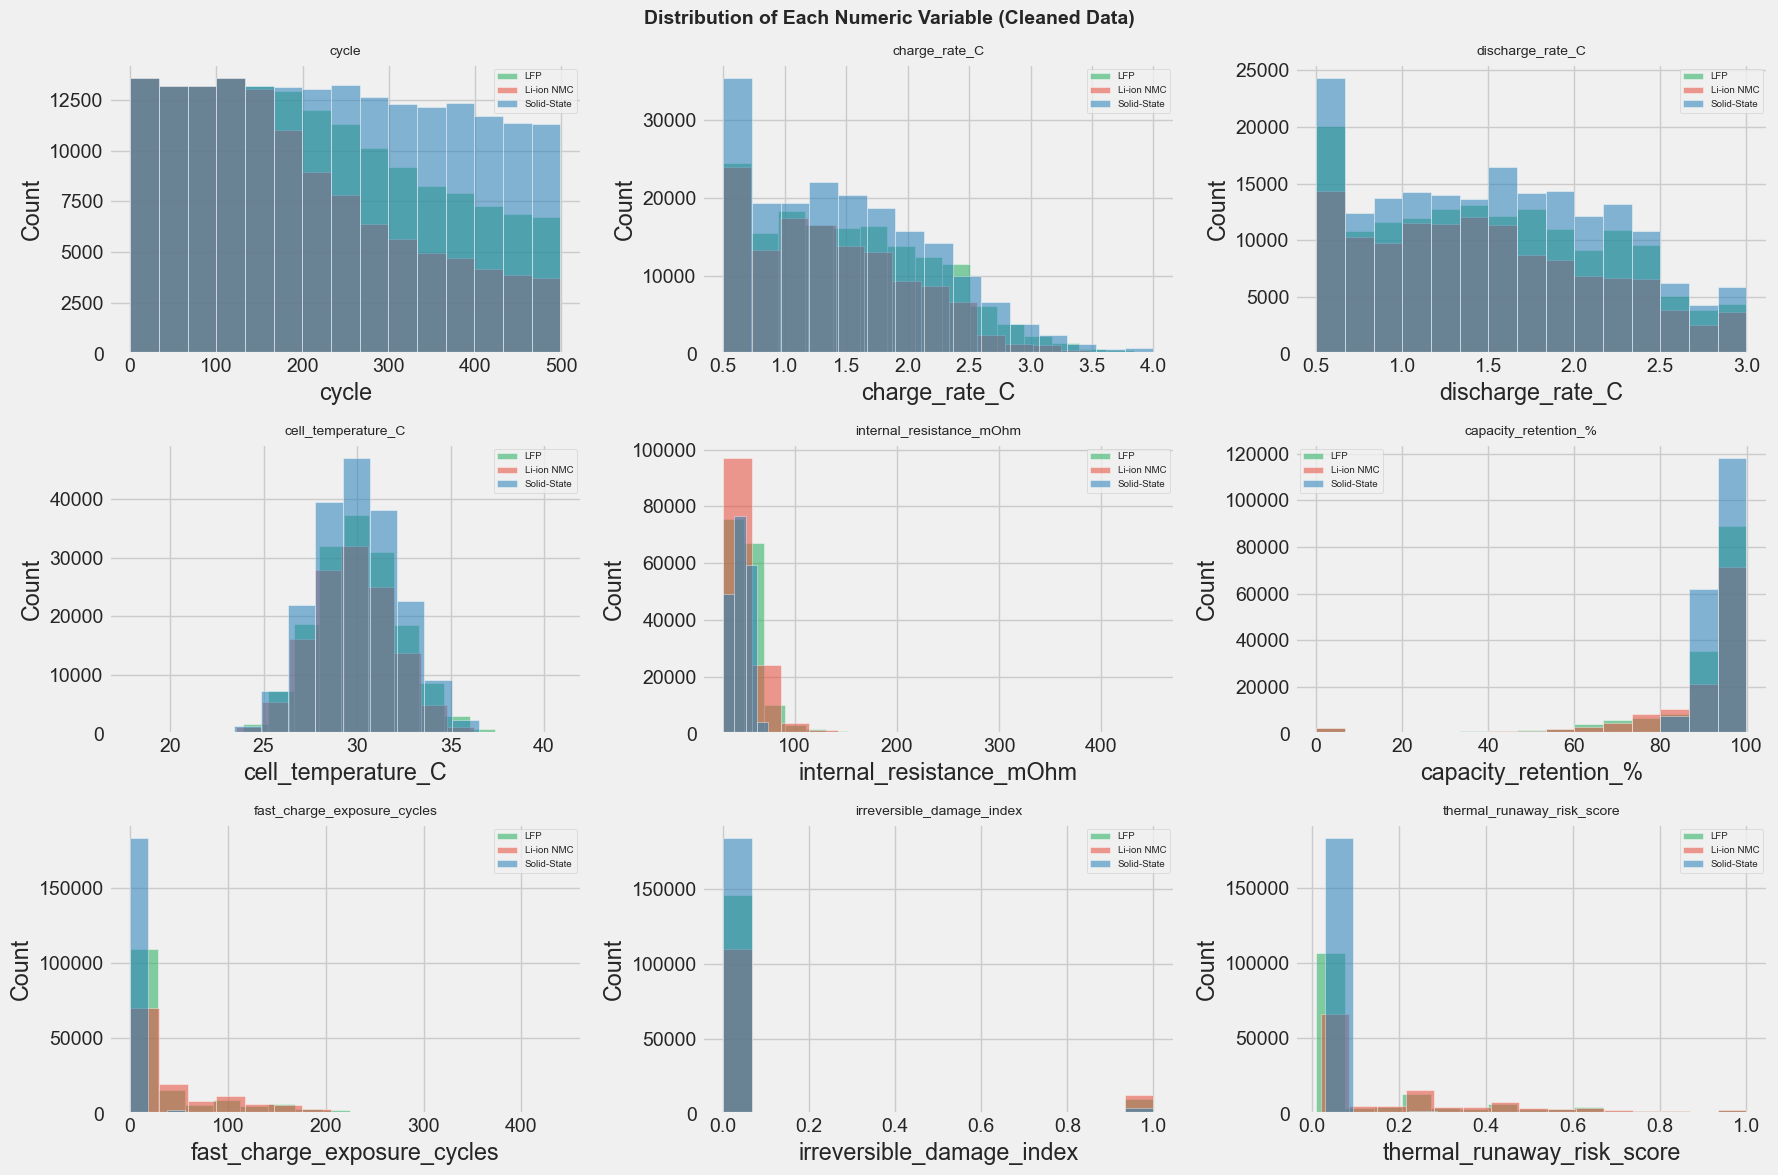

In [159]:
# ###########################################################################
# CLEANED DATA VISUALIZATIONS
# ###########################################################################
print("\n" + "=" * 70)
print(" VISUALIZE Cleaned-up Data")
print("=" * 70)

df = df.sort_values(["cell_chemistry", "cycle"]).reset_index(drop=True)

chemistries = sorted(df["cell_chemistry"].unique())
num_cols = [c for c in df.select_dtypes(include="number").columns]
palette = [chem_color(c) for c in chemistries]

print(f"  Cleaned shape : {df.shape}")
print(f"  Columns       : {list(df.columns)}")
print(f"  Chemistries   : {chemistries}")
print(f"  Numeric cols  : {num_cols}")

# Create UC Berkeley datascience Table for reference
tbl = Table.from_df(df.reset_index(drop=True))
print(f"  datascience Table : {tbl.num_rows} rows x {tbl.num_columns} cols")

print("\n--- Distribution Overview ---")

n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig1, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
fig1.suptitle("Distribution of Each Numeric Variable (Cleaned Data)", fontweight="bold")
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    for chem in chemistries:
        vals = df[df["cell_chemistry"] == chem][col].dropna()
        ax.hist(vals, bins=15, alpha=0.55, label=chem, color=chem_color(chem), edgecolor="white", linewidth=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()
# Uncomment to save the plots to a file
# save(fig1, "cleaned_dataset_distributions.png")


 Main Variable - Which Chemistry Has Lowest Capacity Fade Rate?
       cell_chemistry  cycle  capacity_retention_%  capacity_fade_rate
0                 LFP      0             99.970177                 NaN
1                 LFP      0             99.971970            0.001788
2                 LFP      0             99.966476           -0.005496
3                 LFP      0             99.971077            0.004601
4                 LFP      0             99.976784            0.005710
...               ...    ...                   ...                 ...
477248    Solid-State    499             92.880257            1.633632
477249    Solid-State    499             82.371140          -11.314696
477250    Solid-State    499             85.916473            4.304099
477251    Solid-State    499             91.152557            6.094384
477252    Solid-State    499             93.277855            2.331579

[477253 rows x 4 columns]


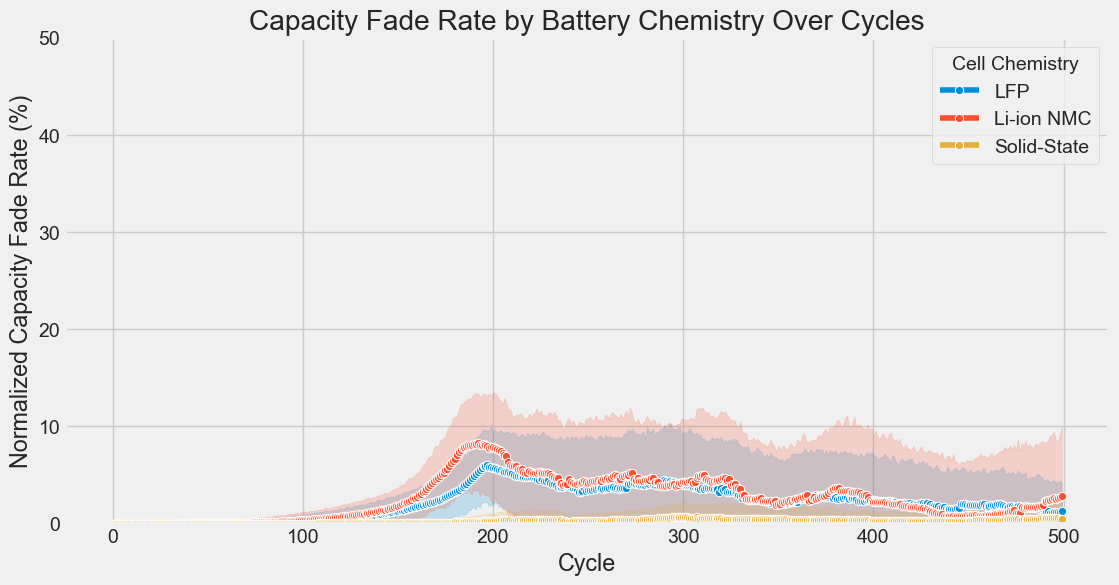

In [161]:
# ###########################################################################
# 2. CREATE RESEARCH VARIABLES
# ###########################################################################

# --- 2a. Main Variable - Capacity Fade Rate --------------------------------
print("\n" + "=" * 70)
# This metric indicates how quickly each battery chemistry loses capacity cycle-over-cycle
print(" Main Variable - Which Chemistry Has Lowest Capacity Fade Rate?")
print("=" * 70)

# calculate capacity fade
df['capacity_fade_rate'] = df.groupby('cell_chemistry')['capacity_retention_%'].pct_change() * 100
print(df[['cell_chemistry', 'cycle', 'capacity_retention_%', 'capacity_fade_rate']])

# Cap the values
df['capacity_fade_rate'] = df['capacity_fade_rate'].clip(lower=-100, upper=100)

# Min-Max Normalization
min_val = df['capacity_fade_rate'].min()
max_val = df['capacity_fade_rate'].max()
df['normalized_capacity_fade_rate'] = (df['capacity_fade_rate'] - min_val) / (max_val - min_val) * 100

# plot results
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='cycle', y='capacity_fade_rate', hue='cell_chemistry', marker='o')

# plot results
plt.title('Capacity Fade Rate by Battery Chemistry Over Cycles')
plt.xlabel('Cycle')
plt.ylabel('Normalized Capacity Fade Rate (%)')
plt.ylim(0,50)
plt.legend(title='Cell Chemistry')
plt.grid(True)




# save jpeg
plt.savefig('normalized_capacity_fade_rate.jpg', dpi=300, bbox_inches='tight')


plt.show()


In [173]:
print("\n" + "=" * 70)
print(" Additional Research Variables ")
print("=" * 70)

df = df.sort_values(["cell_chemistry", "cycle"]).reset_index(drop=True)

# --- 2b. Resistance Growth Rate ------------------------------------------
print("\n--- Which Chemistry Has the Lowest Resistance Growth Rate? ---")
# Tracks how fast internal resistance builds up cycle-over-cycle.

df["resistance_growth_rate"] = (
    df.groupby("cell_chemistry", observed=True)["internal_resistance_mOhm"]
    .diff().astype("float32")
)
df["resistance_growth_rate"] = df["resistance_growth_rate"].fillna(0)
log(f"'resistance_growth_rate' [{df['resistance_growth_rate'].min():.6f}, {df['resistance_growth_rate'].max():.6f}]")

# --- 2c. Temperature Volatility ---------------------------------------
print("\n--- 2c. Temperature Volatility (rolling std, window=5) ---")
# Lower volatility = more thermally stable chemistry.

WINDOW = 5
df["temp_volatility"] = (
    df.groupby("cell_chemistry", observed=True)["cell_temperature_C"]
    .transform(lambda x: x.rolling(window=WINDOW, min_periods=2).std())
    .astype("float32")
)
df["temp_volatility"] = df["temp_volatility"].fillna(0)
log(f"'temp_volatility' [{df['temp_volatility'].min():.4f}, {df['temp_volatility'].max():.4f}]")


# --- 2d. Stress Index (composite normalised score) ------------------------
print("\n--- 2d. Stress Index (composite normalised score) ---")
# Combines charge rate, discharge rate, and temperature into one score.

df["stress_index"] = (
    (minmax(df["charge_rate_C"])
     + minmax(df["discharge_rate_C"])
     + minmax(df["cell_temperature_C"])) / 3.0
).astype("float32")
log(f"'stress_index' [{df['stress_index'].min():.4f}, {df['stress_index'].max():.4f}]")


# --- 2e. Remaining Useful Life Proxy (est. cycles to 80% EOL) -------------
print("\n--- 2e. Remaining Useful Life Proxy (est. cycles to 80%) ---")
# Linear extrapolation from observed fade rate per chemistry.

rul_estimates = {}
for chem, grp in df.groupby("cell_chemistry", observed=True):
    grp = grp.sort_values("cycle")
    if len(grp) < 2:
        continue
    cap0, capN = grp["capacity_retention_%"].iloc[0], grp["capacity_retention_%"].iloc[-1]
    c0, cN = grp["cycle"].iloc[0], grp["cycle"].iloc[-1]
    span = max(cN - c0, 1)
    fade = (cap0 - capN) / span
    rul_estimates[chem] = {
        "fade_per_cycle": fade,
        "est_cycles_to_80pct": round((cap0 - EOL) / fade) if fade > 0 else np.inf,
        "current_min_cap": capN,
    }
rul_df = pd.DataFrame(rul_estimates).T
print("\n  Estimated cycles to reach 80% capacity:")
print(rul_df.to_string())
log("RUL proxy computed for each chemistry")


# --- 2f. Thermal Runaway Risk Category ------------------------------------
print("\n--- 2f. Thermal Runaway Risk Category ---")
# Bin the continuous risk score into actionable categories.

if "thermal_runaway_risk_score" in df.columns:
    df["risk_category"] = pd.cut(
        df["thermal_runaway_risk_score"],
        bins=[-0.01, 0.02, 0.05, 0.10, 1.0],
        labels=["Low", "Medium", "High", "Critical"],
    )
    log(f"'risk_category' -- {df['risk_category'].value_counts().to_dict()}")

print("\n--- Research Variables Preview ---")
preview_cols = ["capacity_fade_rate", "resistance_growth_rate",
                "temp_volatility", "stress_index"]
if "risk_category" in df.columns:
    preview_cols.append("risk_category")
print(df[["cell_chemistry", "cycle"] + preview_cols].head(12).to_string())




 Additional Research Variables 

--- Which Chemistry Has the Lowest Resistance Growth Rate? ---
  -> 'resistance_growth_rate' [-402.795837, 385.340485]

--- 2c. Temperature Volatility (rolling std, window=5) ---
  -> 'temp_volatility' [0.0000, 8.9298]

--- 2d. Stress Index (composite normalised score) ---
  -> 'stress_index' [0.0415, 0.9117]

--- 2e. Remaining Useful Life Proxy (est. cycles to 80%) ---

  Estimated cycles to reach 80% capacity:
             fade_per_cycle  est_cycles_to_80pct  current_min_cap
LFP                0.021788                917.0        89.097893
Li-ion NMC         0.015844               1261.0        92.066170
Solid-State        0.013428               1488.0        93.277855
  -> RUL proxy computed for each chemistry

--- 2f. Thermal Runaway Risk Category ---
  -> 'risk_category' -- {'Medium': 185235, 'Low': 164232, 'Critical': 118681, 'High': 9105}

--- Research Variables Preview ---
   cell_chemistry  cycle  capacity_fade_rate  resistance_growth_rate  te


--- 2c. Temperature Volatility (rolling std, window=5) ---
'temp_volatility' [0.0000, 8.9298]


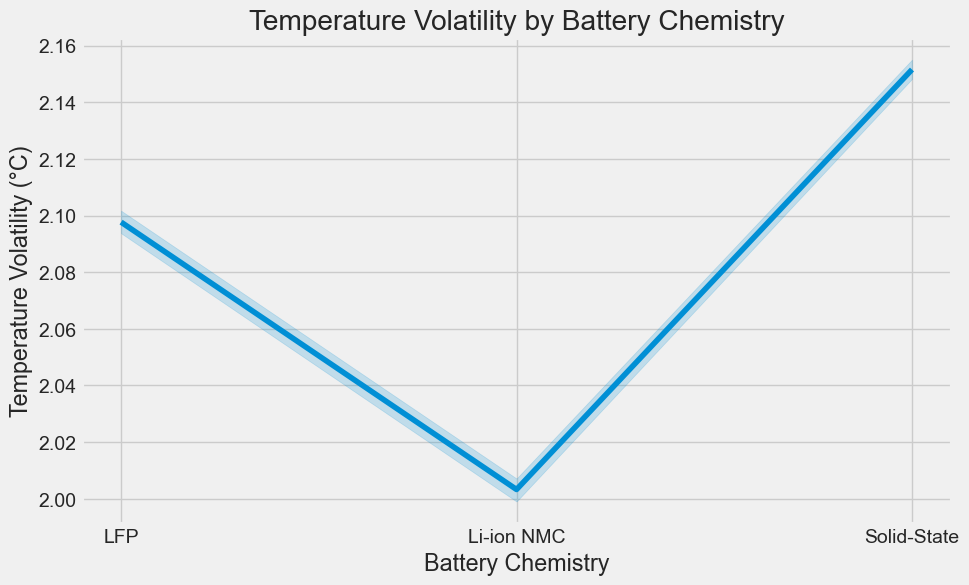

In [175]:
# Hussain code for Temperature Volatility 
print("\n--- 2c. Temperature Volatility (rolling std, window=5) ---")
# Lower volatility = more thermally stable chemistry.

WINDOW = 5
df["temp_volatility"] = (
    df.groupby("cell_chemistry", observed=True)["cell_temperature_C"]
    .transform(lambda x: x.rolling(window=WINDOW, min_periods=2).std())
    .astype("float32")
)

# Fill NaN values with 0
df["temp_volatility"] = df["temp_volatility"].fillna(0)

# Log the min and max of temp_volatility
print(f"'temp_volatility' [{df['temp_volatility'].min():.4f}, {df['temp_volatility'].max():.4f}]")

# Plot results
plt.figure(figsize=(10, 6))
sns.lineplot(x='cell_chemistry', y='temp_volatility', data=df, palette='Blues')

plt.title('Temperature Volatility by Battery Chemistry')
plt.xlabel('Battery Chemistry')
plt.ylabel('Temperature Volatility (°C)')
plt.grid(True)
plt.show()


--- 2d. Stress Index (composite normalised score) ---
  -> 'stress_index' [0.0415, 0.9117]


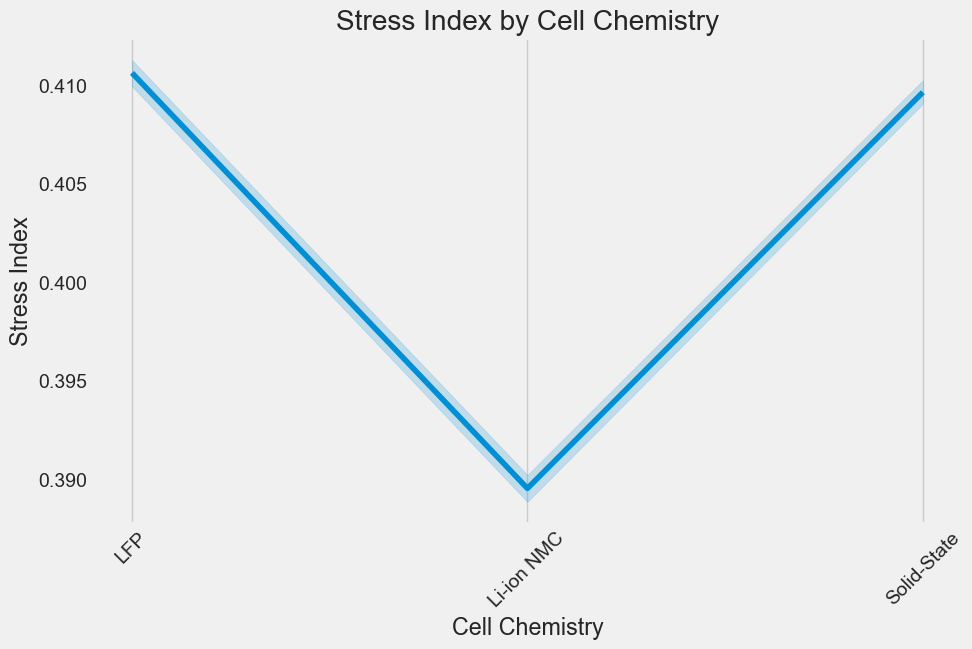

In [177]:
# Hussain code
print("\n--- 2d. Stress Index (composite normalised score) ---")
# Combines charge rate, discharge rate, and temperature into one score.

df["stress_index"] = (
    (minmax(df["charge_rate_C"])
     + minmax(df["discharge_rate_C"])
     + minmax(df["cell_temperature_C"])) / 3.0
).astype("float32")
log(f"'stress_index' [{df['stress_index'].min():.4f}, {df['stress_index'].max():.4f}]")

plt.figure(figsize=(10, 6))
sns.lineplot(x='cell_chemistry', y='stress_index', data=df, palette='Blues')

plt.title('Stress Index by Cell Chemistry')
plt.xlabel('Cell Chemistry')
plt.ylabel('Stress Index')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()



--- 2e. Remaining Useful Life Proxy (est. cycles to 80%) ---


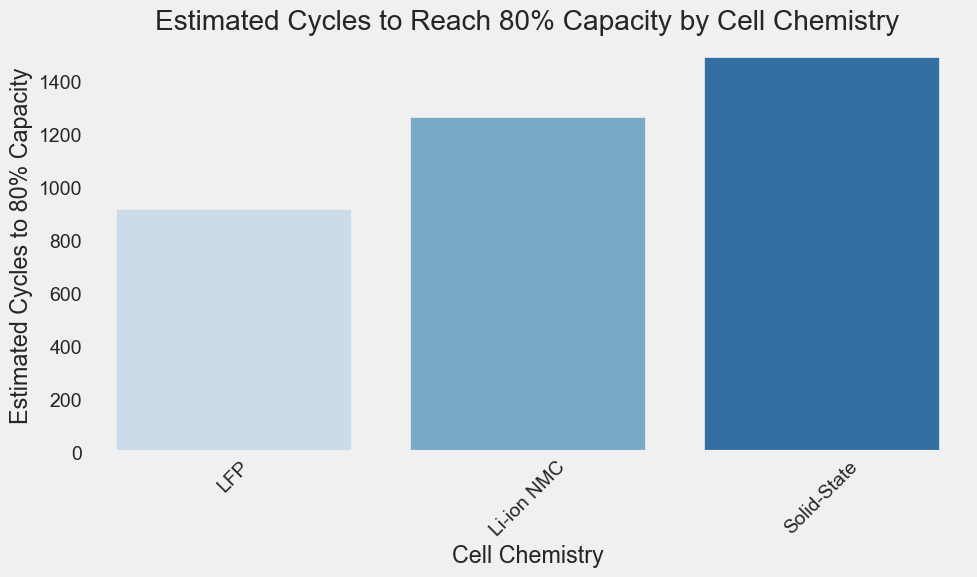

In [179]:
# Hussain Code

# --- 2e. Remaining Useful Life Proxy (est. cycles to 80% EOL) -------------
print("\n--- 2e. Remaining Useful Life Proxy (est. cycles to 80%) ---")
# Linear extrapolation from observed fade rate per chemistry.

rul_estimates = {}
for chem, grp in df.groupby("cell_chemistry", observed=True):
    grp = grp.sort_values("cycle")
    if len(grp) < 2:
        continue
    cap0, capN = grp["capacity_retention_%"].iloc[0], grp["capacity_retention_%"].iloc[-1]
    c0, cN = grp["cycle"].iloc[0], grp["cycle"].iloc[-1]
    span = max(cN - c0, 1)
    fade = (cap0 - capN) / span
    rul_estimates[chem] = {
        "fade_per_cycle": fade,
        "est_cycles_to_80pct": round((cap0 - EOL) / fade) if fade > 0 else np.inf,
        "current_min_cap": capN,
    }


rul_df = pd.DataFrame(rul_estimates).T
rul_df.reset_index(inplace=True)
rul_df.columns = ['cell_chemistry', 'fade_per_cycle', 'est_cycles_to_80pct', 'current_min_cap']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='cell_chemistry', y='est_cycles_to_80pct', data=rul_df, palette='Blues')

# Adding titles and labels
plt.title('Estimated Cycles to Reach 80% Capacity by Cell Chemistry')
plt.xlabel('Cell Chemistry')
plt.ylabel('Estimated Cycles to 80% Capacity')
plt.xticks(rotation=45)  # Rotate x-axis 
plt.grid(axis='y')  

# Show the plot
plt.tight_layout()  
plt.show()



--- 2f. Thermal Runaway Risk Category ---
  -> 'risk_category' -- {'Medium': 185235, 'Low': 164232, 'Critical': 118681, 'High': 9105}

--- Research Variables Preview ---
   cell_chemistry  cycle  capacity_fade_rate  resistance_growth_rate  temp_volatility  stress_index risk_category
0             LFP      0                 NaN                0.000000         0.000000      0.423416           Low
1             LFP      0            0.001788              -17.019028         8.929810      0.457588           Low
2             LFP      0           -0.005496                2.177864         6.587544      0.443160           Low
3             LFP      0            0.004601               -1.129307         6.186678      0.570572           Low
4             LFP      0            0.005710               11.537342         5.778735      0.389677           Low
5             LFP      0           -0.006688               -5.486401         4.195567      0.584716           Low
6             LFP      0       

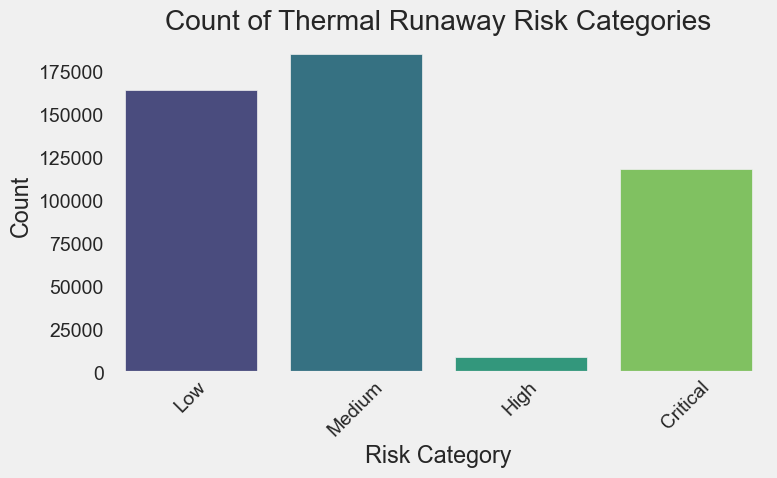

In [181]:
# Hussain Code
# --- 2f. Thermal Runaway Risk Category ------------------------------------
print("\n--- 2f. Thermal Runaway Risk Category ---")
# Bin the continuous risk score into actionable categories.

if "thermal_runaway_risk_score" in df.columns:
    df["risk_category"] = pd.cut(
        df["thermal_runaway_risk_score"],
        bins=[-0.01, 0.02, 0.05, 0.10, 1.0],
        labels=["Low", "Medium", "High", "Critical"],
    )
    log(f"'risk_category' -- {df['risk_category'].value_counts().to_dict()}")

print("\n--- Research Variables Preview ---")
preview_cols = ["capacity_fade_rate", "resistance_growth_rate",
                "temp_volatility", "stress_index"]
if "risk_category" in df.columns:
    preview_cols.append("risk_category")
print(df[["cell_chemistry", "cycle"] + preview_cols].head(12).to_string())

# Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='risk_category', data=df, palette='viridis')

# Adding titles and labels
plt.title('Count of Thermal Runaway Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis
plt.grid(axis='y') 
plt.tight_layout() 
plt.show()


 Q1. Which Chemistry Has Lowest Resistance Growth Rate?


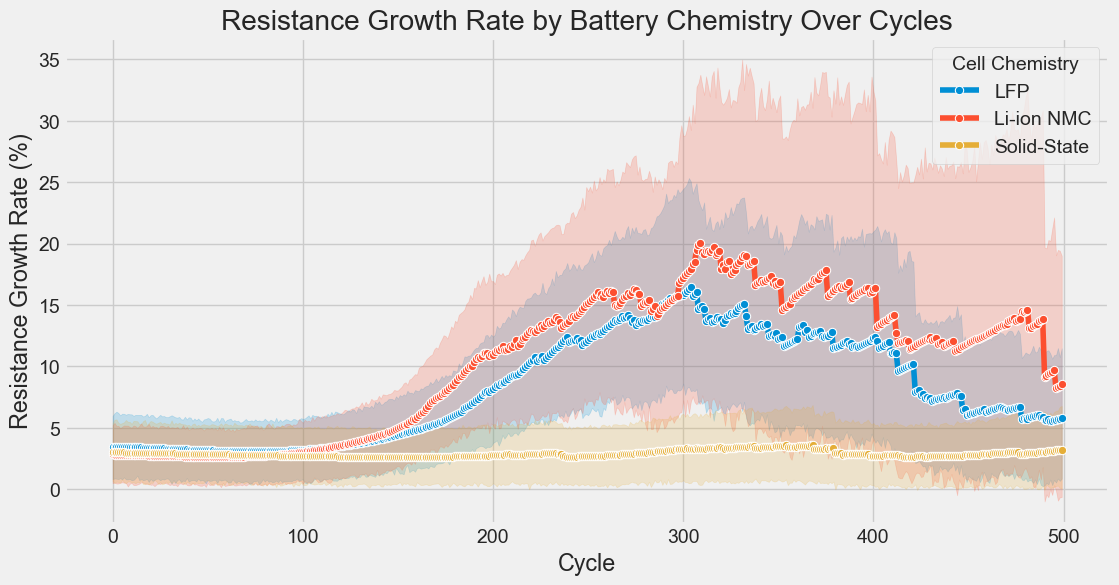

In [183]:
# ###########################################################################
# 3. ANSWER RESEARCH QUESTIONS
# ###########################################################################
print("\n" + "=" * 70)
print(" Q1. Which Chemistry Has Lowest Resistance Growth Rate?") # This measures how fast the internal resistance increases with each cycle.

df['resistance_growth_rate'] = df.groupby('cell_chemistry')['internal_resistance_mOhm'].pct_change() * 100

#df["resistance_growth_rate"] = (df.groupby("cell_chemistry", observed=True)["internal_resistance_mOhm"].diff().astype("float32"))
#print(df)

# plot results
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='cycle', y='resistance_growth_rate', hue='cell_chemistry', marker='o')

plt.title('Resistance Growth Rate by Battery Chemistry Over Cycles')
plt.xlabel('Cycle')
plt.ylabel('Resistance Growth Rate (%)')
plt.legend(title='Cell Chemistry')
plt.grid(True)
plt.show()

In [184]:
tbl = Table.from_df(df.reset_index(drop=True))

# --- Q2. Which chemistry performs best overall? ----------------------
print("\n" + "-" * 70)
print(" Q2. Which chemistry performs best under various metrics?")
print("-" * 70)

scorecard = pd.DataFrame(index=chemistries)
scorecard["avg_capacity_%"]      = df.groupby("cell_chemistry", observed=True)["capacity_retention_%"].mean()
scorecard["min_capacity_%"]      = df.groupby("cell_chemistry", observed=True)["capacity_retention_%"].min()
scorecard["avg_resistance_mOhm"] = df.groupby("cell_chemistry", observed=True)["internal_resistance_mOhm"].mean()
scorecard["temp_std_C"]          = df.groupby("cell_chemistry", observed=True)["cell_temperature_C"].std()
scorecard["avg_fade_per_cycle"]  = df.groupby("cell_chemistry", observed=True)["capacity_fade_rate"].mean().abs()
if "thermal_runaway_risk_score" in df.columns:
    scorecard["avg_risk_score"]  = df.groupby("cell_chemistry", observed=True)["thermal_runaway_risk_score"].mean()
if not rul_df.empty:
    scorecard["est_cycles_to_80%"] = rul_df["est_cycles_to_80pct"]

print("\n  CHEMISTRY PERFORMANCE SCORECARD:")
print(scorecard.round(4).to_string())

# Ranking (1 = best)
ranks = pd.DataFrame(index=chemistries)
ranks["rank_capacity"]   = scorecard["avg_capacity_%"].rank(ascending=False)
ranks["rank_resistance"] = scorecard["avg_resistance_mOhm"].rank(ascending=True)
ranks["rank_temp_stab"]  = scorecard["temp_std_C"].rank(ascending=True)
ranks["rank_fade_rate"]  = scorecard["avg_fade_per_cycle"].rank(ascending=True)
if "avg_risk_score" in scorecard.columns:
    ranks["rank_safety"] = scorecard["avg_risk_score"].rank(ascending=True)
if "est_cycles_to_80%" in scorecard.columns:
    ranks["rank_longevity"] = scorecard["est_cycles_to_80%"].rank(ascending=False)
ranks["TOTAL"] = ranks.sum(axis=1)
ranks = ranks.sort_values("TOTAL")

print("\n  Rankings (1 = best):")
print(ranks.to_string())
winner = ranks.index[0]
print(f"\n  >> OVERALL BEST: {winner} (total rank = {ranks.loc[winner, 'TOTAL']:.0f})")



----------------------------------------------------------------------
 Q2. Which chemistry performs best under various metrics?
----------------------------------------------------------------------

  CHEMISTRY PERFORMANCE SCORECARD:
             avg_capacity_%  min_capacity_%  avg_resistance_mOhm  temp_std_C  avg_fade_per_cycle  avg_risk_score  est_cycles_to_80%
LFP               87.905899             0.0            53.883801      2.2507              2.0624          0.1469                NaN
Li-ion NMC        87.361198             0.0            54.084000      2.1682              2.3148          0.2058                NaN
Solid-State       93.822601             0.0            47.779800      2.2698              0.2375          0.0407                NaN

  Rankings (1 = best):
             rank_capacity  rank_resistance  rank_temp_stab  rank_fade_rate  rank_safety  rank_longevity  TOTAL
Solid-State            1.0              1.0             3.0             1.0          1.0           

In [187]:
# ###########################################################################
# VISUALIZATIONS
# ###########################################################################
print("\n" + "=" * 70)
print(" VISUALIZE FINDINGS")
print("=" * 70)


 VISUALIZE FINDINGS


In [189]:
# ###########################################################################
# 2. ENHANCED VISUALIZATIONS
# ###########################################################################


def plot_lifecycle_comparison(df):
    """
    ANALYSIS OBJECTIVE: Performs a longitudinal comparative study of capacity
    retention across diverse cell chemistries. This visualization identifies
    degradation rates and quantifies the operational lifespan relative to
    the 80% End-of-Life (EOL) industry benchmark.
    """
    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df, x="cycle", y="capacity_retention_%", hue="cell_chemistry", palette=CHEM_COLORS, linewidth=2, alpha=0.8
    )

    plt.axhline(y=EOL, color="black", linestyle="--", alpha=0.5, label=f"EOL Threshold ({EOL}%)")
    plt.title("Battery Capacity Retention: NMC vs LFP vs Solid-State", fontsize=14, fontweight="bold")
    plt.xlabel("Cycle Number", fontsize=11)
    plt.ylabel("Retention (%)", fontsize=11)
    plt.ylim(70, 105)
    plt.legend(title="Chemistry", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_stress_correlation(df):
    """
    ANALYSIS OBJECTIVE: Generates an electrochemical correlation matrix to
    evaluate the interdependencies between operational stressors (C-rates,
    Temperature) and degradation metrics. This identifies the primary
    mechanistic drivers of cell failure within the dataset.
    """
    plt.figure(figsize=(10, 8))

    # Selecting the core electrochemical variables
    core_vars = [
        "charge_rate_C",
        "discharge_rate_C",
        "cell_temperature_C",
        "internal_resistance_mOhm",
        "capacity_retention_%",
        "thermal_runaway_risk_score",
    ]
    corr = df[core_vars].corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, cmap="RdYlGn", fmt=".2f", square=True, linewidths=0.5)

    plt.title("Correlation Matrix: Operational Stress vs. Battery Health", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [191]:
def plot_safety_profile(df):
    """
    ANALYSIS OBJECTIVE: Utilizes Box Plots
    to compare safety margins across chemistries. This focuses on identifying
    statistical outliers in 'Thermal Runaway Risk' and 'Irreversible Damage'
    to assess reliability under extreme operational edge-cases.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Thermal Runaway Risk
    sns.boxplot(data=df, x="cell_chemistry", y="thermal_runaway_risk_score", palette=CHEM_COLORS, ax=ax1)
    ax1.set_title("Thermal Runaway Risk Distribution", fontweight="bold")

    # Plot 2: Irreversible Damage Index
    sns.boxplot(data=df, x="cell_chemistry", y="irreversible_damage_index", palette=CHEM_COLORS, ax=ax2)
    ax2.set_title("Irreversible Damage by Chemistry Type", fontweight="bold")

    plt.tight_layout()
    plt.show()

In [193]:
def plot_reliability_milestones(df):
    """
    ANALYSIS OBJECTIVE: Quantifies 'B10 Life'—the operational cycle count
    at which 10% of the fleet reaches the EOL threshold. This provides
    a singular, intuitive metric for comparing commercial reliability.
    """
    # 1. Identify failure points
    df_copy = df.copy()
    df_copy["failed"] = df_copy["capacity_retention_%"] < EOL

    # Calculate failure percentage per cycle for each chemistry
    fail_rates = df_copy.groupby(["cell_chemistry", "cycle"])["failed"].mean().reset_index()

    milestones = []
    for chem in fail_rates["cell_chemistry"].unique():
        subset = fail_rates[fail_rates["cell_chemistry"] == chem]
        # Find the first cycle where at least 10% of the fleet has failed
        b10_match = subset[subset["failed"] >= 0.10]

        if not b10_match.empty:
            b10_cycle = b10_match["cycle"].min()
        else:
            b10_cycle = df["cycle"].max()  # If they never hit 10% failure

        milestones.append({"Chemistry": chem, "B10_Cycle": b10_cycle})

    milestone_df = pd.DataFrame(milestones)

    # 2. Plotting the Bar Chart
    plt.figure(figsize=(10, 6))
    sns.barplot(data=milestone_df, x="Chemistry", y="B10_Cycle", palette=CHEM_COLORS)

    plt.title("Reliability Milestone: Cycles until 10% Failure (B10 Life)", fontsize=14, fontweight="bold")
    plt.ylabel("Cycle Number at 10% Failure")
    plt.xlabel("Battery Chemistry")

    # Add data labels on top of the bars
    for i, val in enumerate(milestone_df["B10_Cycle"]):
        plt.text(i, val + 5, f"{int(val)} Cycles", ha="center", fontweight="bold", fontsize=12)

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [195]:
def plot_thermal_resilience_bars(df):
    """
    ANALYSIS OBJECTIVE: Categorical Thermal Stability.
    Groups temperature into bins to show exactly how much health is
    maintained at specific 'Stress Zones.'
    """
    # 1. Create Temperature Bins (e.g., Cool, Room, Warm, Hot)
    df_bins = df.copy()
    bins = [0, 25, 35, 45, 60]
    labels = ["Cool (<25°C)", "Optimal (25-35°C)", "Warm (35-45°C)", "Hot (>45°C)"]
    df_bins["Temp_Zone"] = pd.cut(df_bins["cell_temperature_C"], bins=bins, labels=labels)

    # 2. Setup the Plot (Bar Chart style like the B10 chart)
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # Plotting the mean retention for each zone
    ax = sns.barplot(
        data=df_bins,
        x="Temp_Zone",
        y="capacity_retention_%",
        hue="cell_chemistry",
        palette=CHEM_COLORS,
        edgecolor="black",
        errorbar=None,
    )

    # 3. Adding an 80% threshold
    plt.axhline(y=80, color="red", linestyle="--", linewidth=2, label="80% EOL Threshold")

    # 4. formatting
    plt.title("Comparative Thermal Resilience: Retention by Temperature Zone", fontsize=16, fontweight="bold")
    plt.xlabel("Operational Temperature Environment", fontsize=12)
    plt.ylabel("Average Capacity Retention (%)", fontsize=12)
    plt.ylim(70, 105)

    # moving legend to lefthand side
    plt.legend(title="Battery Chemistry", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

In [197]:
def plot_thermal_retention_profile(df):
    """
    ANALYSIS OBJECTIVE: Evaluates 'Thermal Degradation Sensitivity.'
    """
    # Sampling 50k for performance and clarity
    df_sample = df.sample(n=min(50000, len(df)), random_state=42)

    g = sns.lmplot(
        data=df_sample,
        x="cell_temperature_C",
        y="capacity_retention_%",
        hue="cell_chemistry",
        palette=CHEM_COLORS,
        scatter_kws={"alpha": 0.05, "s": 4},
        line_kws={"linewidth": 3},
        aspect=1.5,
        height=6,
        legend=False,
    )

    ax = g.ax

    # Creating the legends with lines
    line_handles = [
        mlines.Line2D([], [], color=color, label=label, linewidth=4) for label, color in CHEM_COLORS.items()
    ]

    # Place the legend OUTSIDE the graph to the right
    ax.legend(
        handles=line_handles,
        title="Battery Chemistry",
        bbox_to_anchor=(1.02, 1),  # Moves it slightly to the right of the plot
        loc="upper left",
        borderaxespad=0.0,
        frameon=True,
        shadow=True,
    )

    plt.title("Thermal Resilience: Capacity Retention vs. Temperature", fontsize=14, fontweight="bold")
    plt.xlabel("Cell Temperature (°C)")
    plt.ylabel("Capacity Retention (%)")
    plt.grid(True, alpha=0.1)

    plt.tight_layout()
    plt.show()

Generating Enhanced Visuals


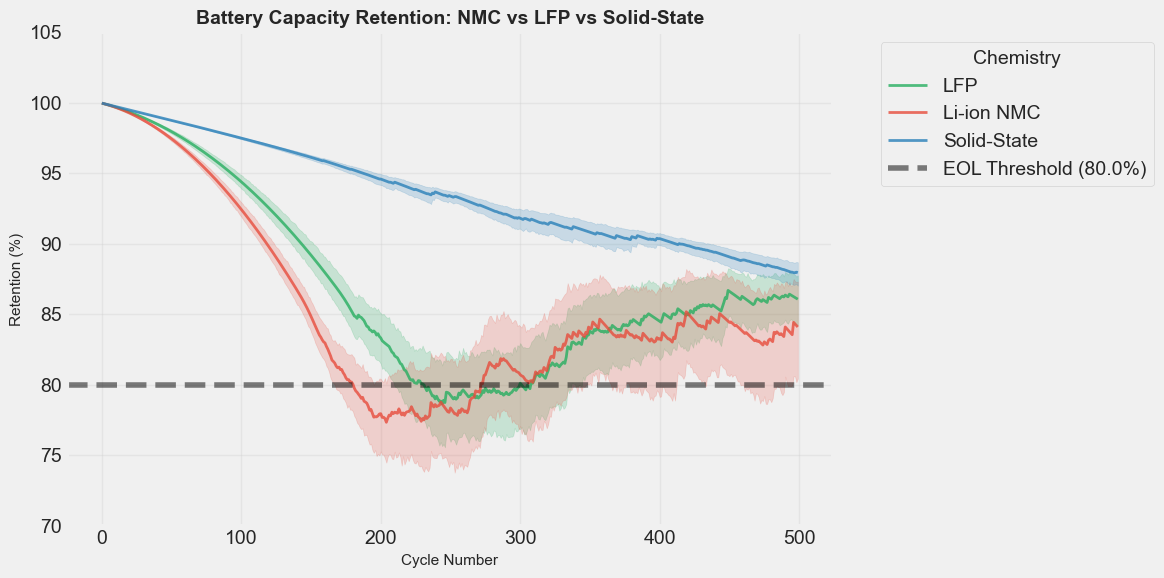

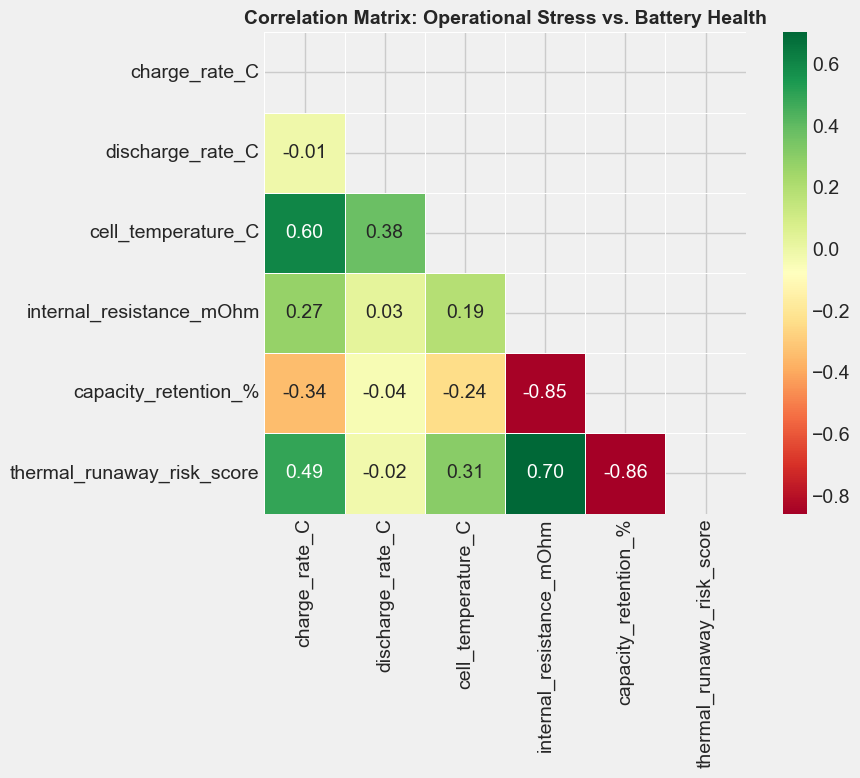

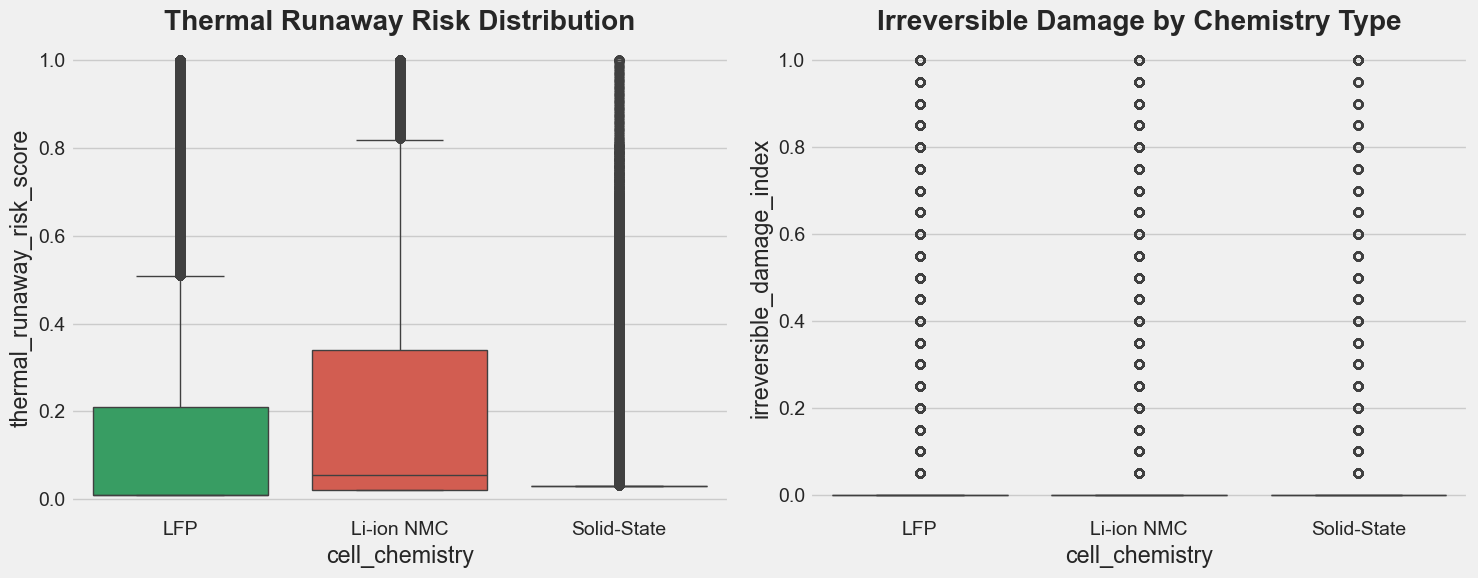

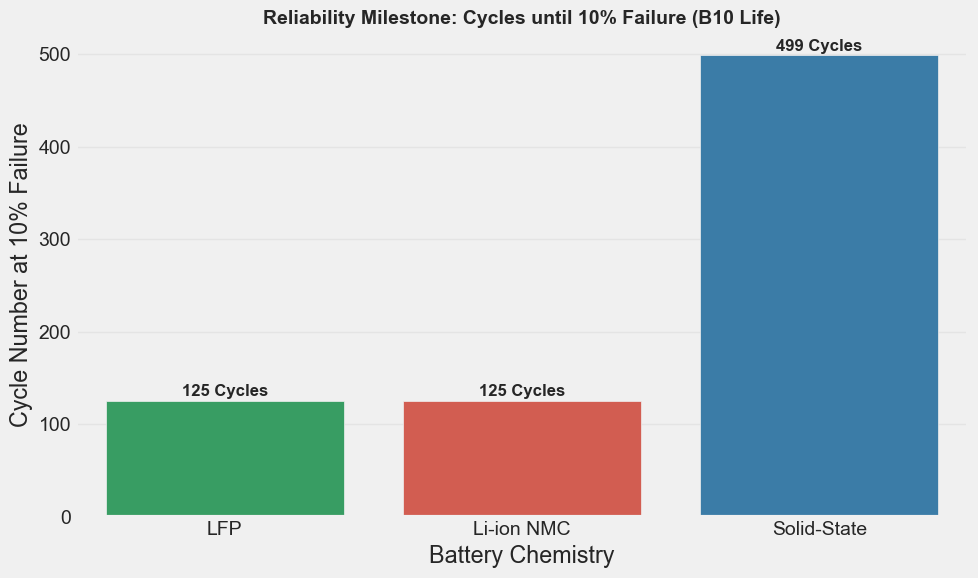

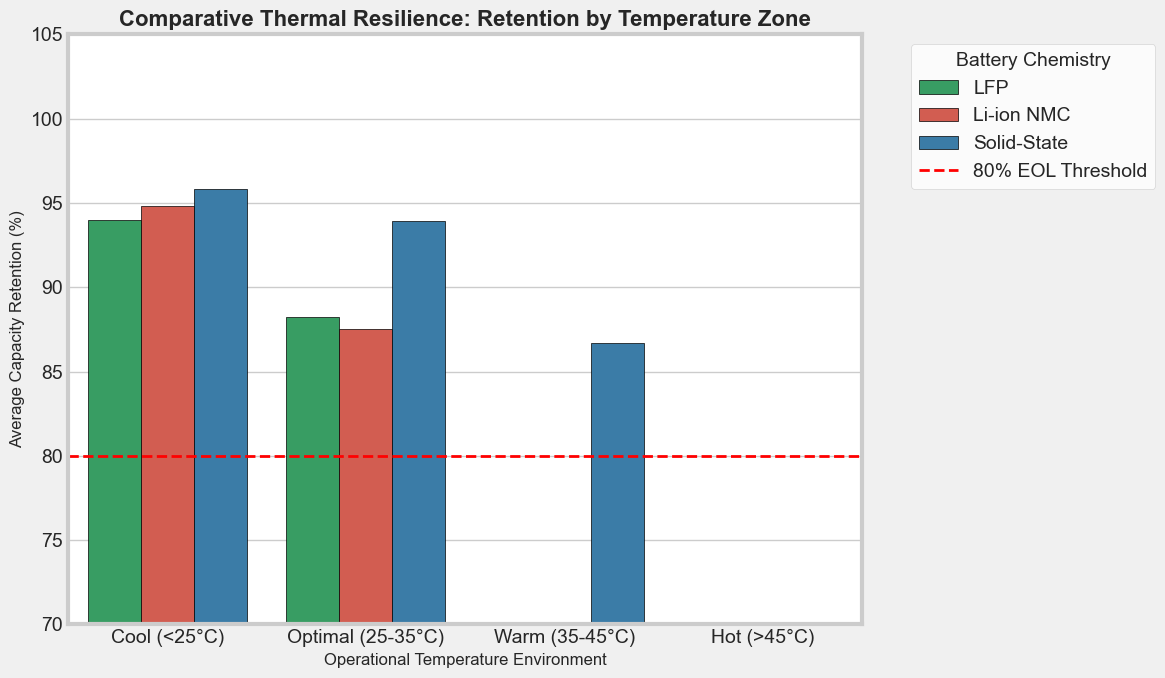

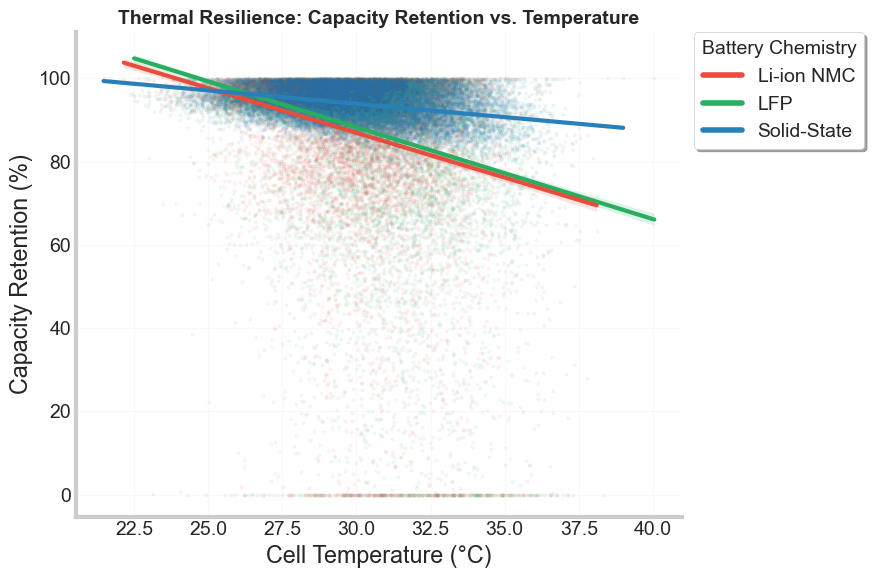

In [199]:
print("Generating Enhanced Visuals")

# 1. Comparative Analysis: Longitudinal Capacity Retention
# This identifies when each chemistry hits the 80% EOL threshold.
plot_lifecycle_comparison(df)

# 2. Multivariate Analysis: Electrochemical Stress Correlation
# This identifies the primary mechanistic drivers of battery failure.
plot_stress_correlation(df)

# 3. Distribution Analysis: Safety Risk & Integrity Metrics
# This quantifies the variance in thermal risk and structural damage.
plot_safety_profile(df)

# 4. Reliability Analysis: Fleet Survival Probability
# This calculates the percentage of the 'fleet' still functional over time.
plot_reliability_milestones(df)

# 5. Sensitivity Analysis: Thermal Degradation Resilience
# This evaluates the 'breaking point' of each chemistry by mapping
# capacity loss directly against operational temperature.
plot_thermal_resilience_bars(df)

# 6. Predictive Modeling: Remaining Useful Life (RUL) Estimation
# This projects the 'Runway' for each battery, forecasting the
# remaining cycles before reaching the 80% EOL threshold.
plot_thermal_retention_profile(df)